mkdir -p failed for path C:\Users\Külkedisi\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Külkedisi\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\KLKEDI~1\AppData\Local\Temp\matplotlib-38ug18ei because there was an issue with the default path (C:\Users\Külkedisi\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



=== Random LR Search Başlıyor ===

>>> Deneme 1/5 | LR: 0.000133


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\torch_cache\hub\checkpoints\resnet34-b627a593.pth
100.0%


   Val Acc: %90.96
   --> (!) Şu ana kadarki en iyi sonuç bu!

>>> Deneme 2/5 | LR: 0.007114
   Val Acc: %91.13
   --> (!) Şu ana kadarki en iyi sonuç bu!

>>> Deneme 3/5 | LR: 0.001570
   Val Acc: %91.03

>>> Deneme 4/5 | LR: 0.000625
   Val Acc: %92.95
   --> (!) Şu ana kadarki en iyi sonuç bu!

>>> Deneme 5/5 | LR: 0.000029
   Val Acc: %87.31

>>> KAZANAN LEARNING RATE: 0.000625

🚀 Head Training Başlıyor
Ep 1: Train Loss 0.680 | Val Acc %90.99 | Val ROC 0.0000
Ep 2: Train Loss 0.394 | Val Acc %93.02 | Val ROC 0.0000
Ep 3: Train Loss 0.324 | Val Acc %93.08 | Val ROC 0.0000
Ep 4: Train Loss 0.284 | Val Acc %93.08 | Val ROC 0.0000
Ep 5: Train Loss 0.256 | Val Acc %93.25 | Val ROC 0.0000

🔥 Fine-Tuning Başlıyor (son 2 bloğu açıyoruz)
Layerler artık güncellenebilir!
Ep 1: Train Loss 0.260 | Val Acc %94.87 | Val ROC 0.0000
Ep 2: Train Loss 0.087 | Val Acc %96.19 | Val ROC 0.0000
Ep 3: Train Loss 0.046 | Val Acc %95.24 | Val ROC 0.0000
Ep 4: Train Loss 0.033 | Val Acc %95.85 | Val ROC 0.00

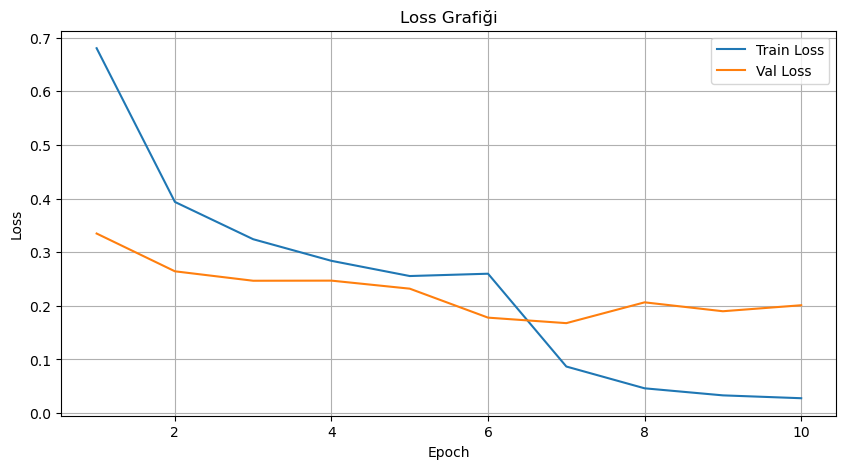

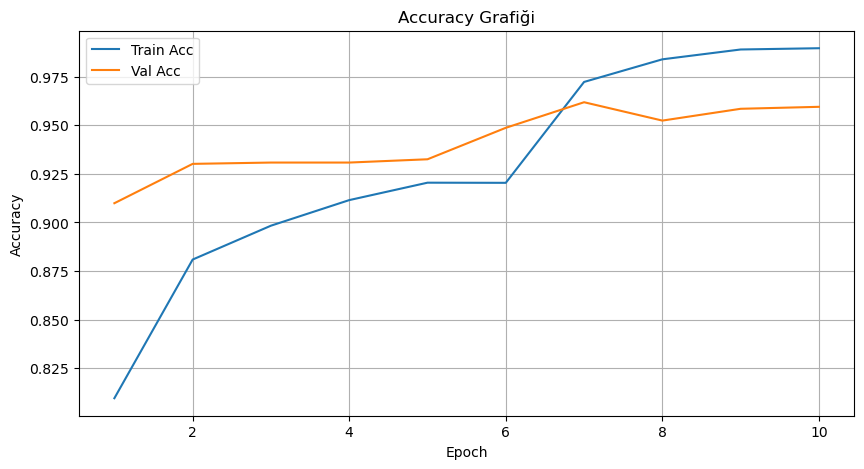

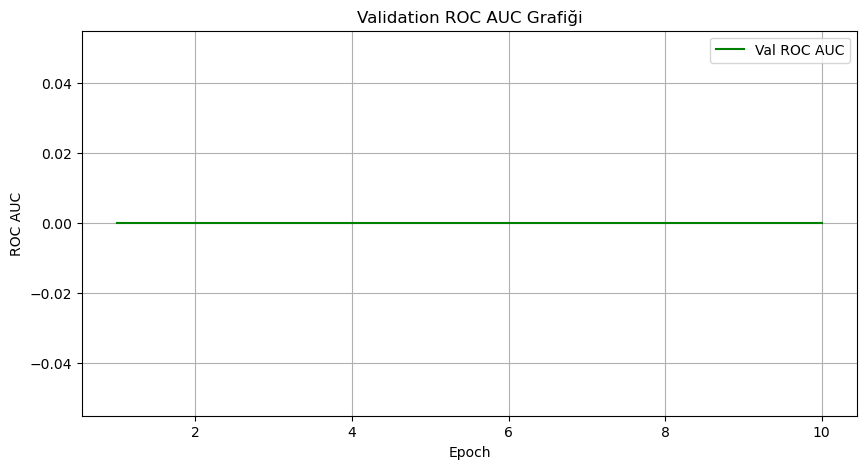

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import random
import os


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


os.environ["TORCH_HOME"] = r"C:\torch_cache"
os.makedirs(os.environ["TORCH_HOME"], exist_ok=True)


DATA_DIR = r'C:\Users\Külkedisi\Desktop\DLP Batch\garbage-dataset'
BATCH_SIZE = 32

data_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=data_transforms)
classes = dataset.classes
targets = dataset.targets

train_idx, temp_idx = train_test_split(range(len(dataset)), test_size=0.3, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42)

train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(Subset(dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False)


class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


def get_resnet34(num_classes, pretrained=True):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)
    
    # Head training için backbone frozen
    for p in model.parameters():
        p.requires_grad = False
    
    in_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0,0,0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return running_loss / len(loader.dataset), correct/total

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0,0,0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)
            running_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
            all_probs.append(torch.softmax(out, dim=1).cpu())
            all_labels.append(y.cpu())
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)
    try:
        roc = roc_auc_score(all_labels.numpy(), all_probs[:,1].numpy())
    except:
        roc = 0.0
    return running_loss / len(loader.dataset), correct/total, roc


lr_candidates = [10**np.random.uniform(-5,-2) for _ in range(5)]
best_lr, best_acc = None, 0
print("\n=== Random LR Search Başlıyor ===")
for lr_idx, lr in enumerate(lr_candidates):
    print(f"\n>>> Deneme {lr_idx+1}/{len(lr_candidates)} | LR: {lr:.6f}")
    temp_model = get_resnet34(len(classes))
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    for epoch in range(3):
        train_one_epoch(temp_model, train_loader, criterion, optimizer)
    _, val_acc, _ = validate(temp_model, val_loader, criterion)
    print(f"   Val Acc: %{val_acc*100:.2f}")
    if val_acc > best_acc:
        best_acc = val_acc
        best_lr = lr
        print(f"   --> (!) Şu ana kadarki en iyi sonuç bu!")
del temp_model
torch.cuda.empty_cache()
print(f"\n>>> KAZANAN LEARNING RATE: {best_lr:.6f}")


FULL_EPOCHS_HEAD = 5
FULL_EPOCHS_FINE = 20
PATIENCE = 3

model = get_resnet34(len(classes))
optimizer = optim.Adam(model.fc.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS_HEAD)

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_roc':[]}
best_val = 0
patience_counter = 0


print("\n🚀 Head Training Başlıyor")
for epoch in range(FULL_EPOCHS_HEAD):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va, vr = validate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)
    history['val_roc'].append(vr)
    print(f"Ep {epoch+1}: Train Loss {tl:.3f} | Val Acc %{va*100:.2f} | Val ROC {vr:.4f}")
    
    if va > best_val:
        best_val = va
        torch.save(model.state_dict(), 'best_model_resnet34.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping tetiklendi!")
            break


print("\n🔥 Fine-Tuning Başlıyor (son 2 bloğu açıyoruz)")
for p in model.layer4.parameters():
    p.requires_grad = True
print("Layerler artık güncellenebilir!")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=best_lr/10)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS_FINE)

for epoch in range(FULL_EPOCHS_FINE):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
    vl, va, vr = validate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)
    history['val_roc'].append(vr)
    print(f"Ep {epoch+1}: Train Loss {tl:.3f} | Val Acc %{va*100:.2f} | Val ROC {vr:.4f}")
    
    if va > best_val:
        best_val = va
        torch.save(model.state_dict(), 'best_model_resnet34.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping tetiklendi!")
            break


epochs = range(1,len(history['train_loss'])+1)
plt.figure(figsize=(10,5))
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title("Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, history['train_acc'], label='Train Acc')
plt.plot(epochs, history['val_acc'], label='Val Acc')
plt.title("Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, history['val_roc'], label='Val ROC AUC', color='green')
plt.title("Validation ROC AUC Grafiği")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True)
plt.show()


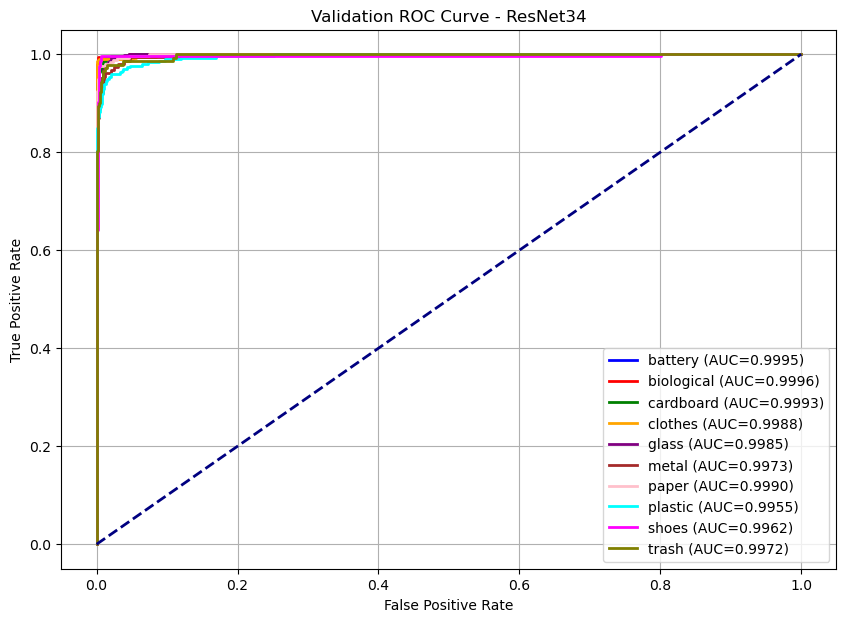

In [8]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision import models
from itertools import cycle


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_resnet34(num_classes, pretrained=False):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)
    
    in_ftrs = model.fc.in_features
    model.fc = torch.nn.Sequential(
        torch.nn.Linear(in_ftrs, 256),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(256, num_classes)
    )
    return model.to(device)

num_classes = len(classes)  
model = get_resnet34(num_classes, pretrained=False)


model.load_state_dict(torch.load('best_model_resnet34.pth', map_location=device, weights_only=True))
model.eval()


all_probs, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_probs.append(torch.softmax(out, dim=1).cpu())
        all_labels.append(y.cpu())

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)


if num_classes == 2: 
    fpr, tpr, _ = roc_curve(all_labels.numpy(), all_probs[:,1].numpy())
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Validation ROC Curve - ResNet34')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:  # Multi-class sınıflandırma
    y_true = label_binarize(all_labels.numpy(), classes=range(num_classes))
    fpr, tpr, roc_auc_dict = dict(), dict(), dict()
    colors = ['blue','red','green','orange','purple','brown','pink','cyan','magenta','olive']
    
    plt.figure(figsize=(10,7))
    for i, color in zip(range(num_classes), cycle(colors)):
        fpr[i], tpr[i], _ = roc_curve(y_true[:,i], all_probs[:,i].numpy())
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{classes[i]} (AUC={roc_auc_dict[i]:.4f})')
    
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Validation ROC Curve - ResNet34')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_24476\1229432125.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('best_model_resn

Accuracy: 0.9619
F1-score (weighted): 0.9619
Cohen's Kappa: 0.9556
Precision (weighted): 0.9623
Recall (weighted): 0.9619

Classification Report:
              precision    recall  f1-score   support

     battery       0.94      0.99      0.96       142
  biological       0.96      0.99      0.97       150
   cardboard       0.97      0.96      0.97       274
     clothes       1.00      0.98      0.99       799
       glass       0.98      0.94      0.96       459
       metal       0.91      0.91      0.91       153
       paper       0.95      0.98      0.96       252
     plastic       0.91      0.93      0.92       297
       shoes       0.95      0.99      0.97       296
       trash       0.95      0.89      0.92       142

    accuracy                           0.96      2964
   macro avg       0.95      0.96      0.95      2964
weighted avg       0.96      0.96      0.96      2964



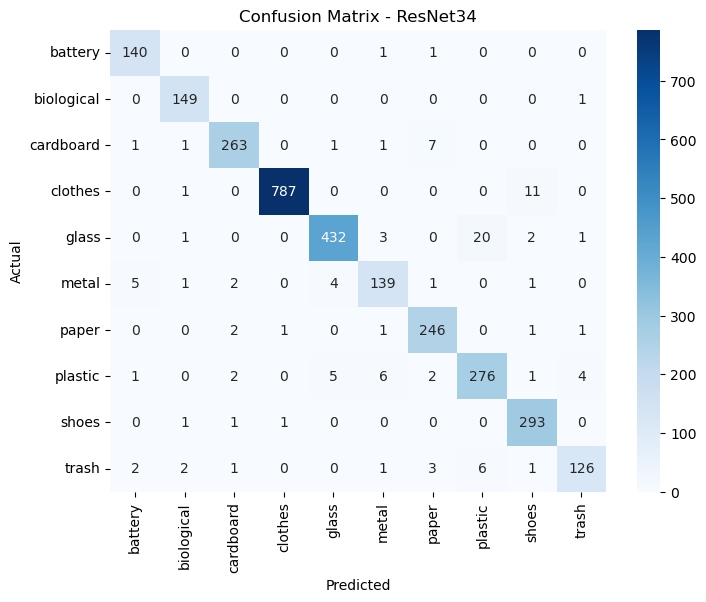

In [11]:
import torch
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report, precision_score,
                             recall_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

final_model = get_resnet34(len(classes))


final_model.load_state_dict(torch.load('best_model_resnet34.pth', map_location=device))
final_model.eval()  


final_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = final_model(x)
        preds = torch.argmax(out, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()


acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
kappa = cohen_kappa_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet34")
plt.show()


C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_24476\1680014111.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('best_model_resn

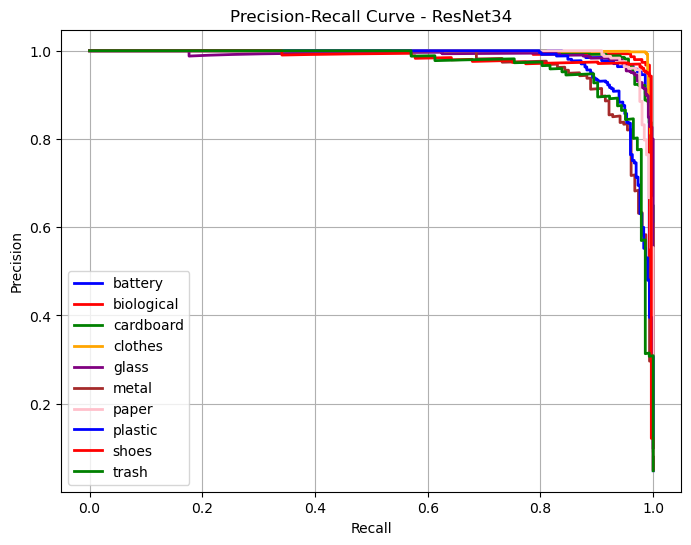

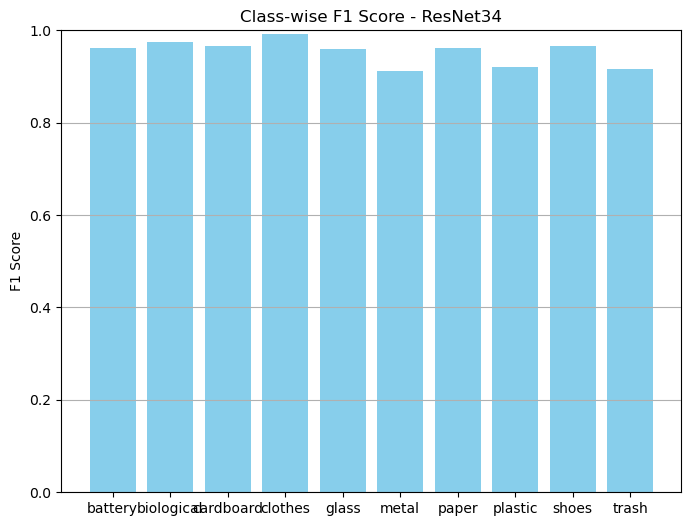

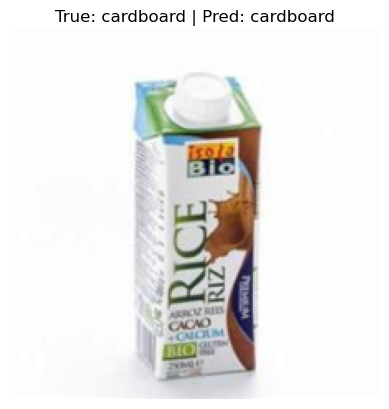

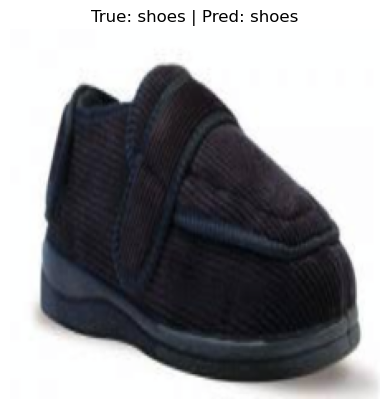

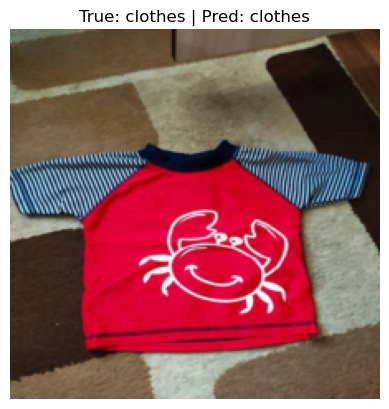

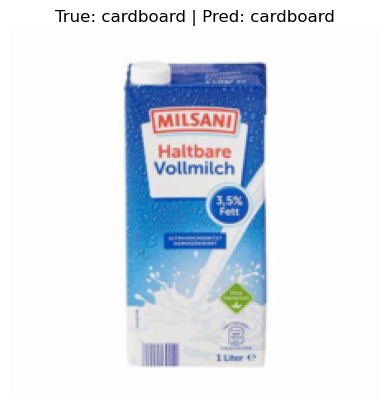

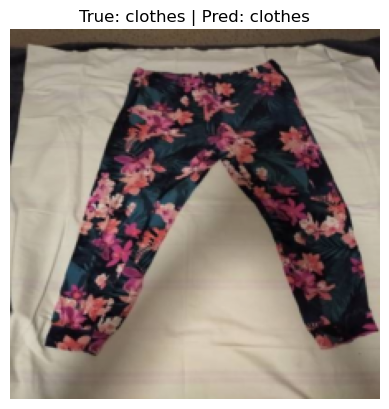

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score
from itertools import cycle
import random
import torchvision


final_model = get_resnet34(len(classes))  # Daha önce tanımladığın fonksiyon
final_model.load_state_dict(torch.load('best_model_resnet34.pth', map_location=device))
final_model.eval()


all_probs, all_labels, all_preds = [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = final_model(x)
        probs = torch.softmax(out, dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(y.cpu())
        all_preds.append(probs.argmax(1).cpu())

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

num_classes = all_probs.shape[1]
class_names = classes  
colors = ['blue','red','green','orange','purple','brown','pink']


plt.figure(figsize=(8,6))
for i, color in zip(range(num_classes), cycle(colors)):
    precision, recall, _ = precision_recall_curve(
        label_binarize(all_labels.numpy(), classes=range(num_classes))[:, i],
        all_probs[:, i].numpy()
    )
    plt.plot(recall, precision, color=color, lw=2, label=f'{class_names[i]}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - ResNet34')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


f1_scores = f1_score(all_labels.numpy(), all_preds.numpy(), average=None)

plt.figure(figsize=(8,6))
plt.bar(class_names, f1_scores, color='skyblue')
plt.ylim(0,1)
plt.ylabel('F1 Score')
plt.title('Class-wise F1 Score - ResNet34')
plt.grid(axis='y')
plt.show()


examples = random.sample(range(len(test_loader.dataset)), 5)
for idx in examples:
    img, label = test_loader.dataset[idx]
    img_display = img.permute(1,2,0).numpy()  # CHW -> HWC
    img_display = img_display * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_display = np.clip(img_display, 0, 1)
    
    final_model.eval()
    with torch.no_grad():
        x = img.unsqueeze(0).to(device)
        out = final_model(x)
        pred_class = class_names[out.argmax(1).item()]
    
    plt.figure()
    plt.imshow(img_display)
    plt.title(f'True: {class_names[label]} | Pred: {pred_class}')
    plt.axis('off')
    plt.show()


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = r"C:\Users\Külkedisi\Desktop\DLP Batch\garbage-dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
classes = dataset.classes
num_classes = len(classes)

targets = [s[1] for s in dataset.samples]

_, temp_idx = train_test_split(range(len(dataset)), test_size=0.3,
                               stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]

_, test_idx = train_test_split(temp_idx, test_size=0.5,
                               stratify=temp_targets, random_state=42)

test_loader = DataLoader(Subset(dataset, test_idx),
                         batch_size=32, shuffle=False)

model = models.resnet34(weights=None)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),  # 🔴 256 OLACAK
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)             # 🔴 256 → num_classes
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        r"C:\Users\Külkedisi\Desktop\DLP Batch\best_model_resnet34.pth",
        map_location=device
    )
)

model.eval()


all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

rows = []
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

for i, name in enumerate(classes):
    y_true = (all_labels == i).astype(int)
    y_pred = (all_preds == i).astype(int)

    rows.append({
        "Class": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Class Accuracy": accuracy_score(y_true, y_pred),
        "Support": y_true.sum()
    })

resnet_df = pd.DataFrame(rows)
print(resnet_df)



C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_3044\3689349289.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


        Class  Precision    Recall  F1-score  Class Accuracy  Support
0     battery   0.985612  0.971631  0.978571        0.997976      141
1  biological   0.947712  0.973154  0.960265        0.995953      149
2   cardboard   0.964029  0.978102  0.971014        0.994604      274
3     clothes   0.997472  0.987484  0.992453        0.995953      799
4       glass   0.951724  0.900000  0.925140        0.977403      460
5       metal   0.867089  0.895425  0.881029        0.987521      153
6       paper   0.959184  0.932540  0.945674        0.990894      252
7     plastic   0.896104  0.926174  0.910891        0.981788      298
8       shoes   0.939683  0.996633  0.967320        0.993255      297
9       trash   0.888112  0.894366  0.891228        0.989545      142


In [4]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(test_loader.dataset.dataset.classes)

resnet34 = models.resnet34(weights=None)

resnet34.fc = nn.Sequential(

    nn.Linear(resnet34.fc.in_features, 256),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(256, num_classes)

)


resnet34 = resnet34.to(device)
resnet34.load_state_dict(

    torch.load("best_model_resnet34.pth", map_location=device)

)
resnet34.eval()

def evaluate_general(model, loader):
    all_preds = []
    all_labels = []
    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, prec, rec, f1

res_acc, res_prec, res_rec, res_f1 = evaluate_general(resnet34, test_loader)


print("\n🟥 RESNET-34 GENEL PERFORMANS")
print(f"Accuracy        : {res_acc:.4f}")
print(f"Macro Precision : {res_prec:.4f}")
print(f"Macro Recall    : {res_rec:.4f}")
print(f"Macro F1-Score  : {res_f1:.4f}")

C:\Users\Külkedisi\AppData\Local\Temp\ipykernel_3044\2558995162.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_model_resnet34.pth", map_location=devic


🟥 RESNET-34 GENEL PERFORMANS
Accuracy        : 0.9524
Macro Precision : 0.9397
Macro Recall    : 0.9456
Macro F1-Score  : 0.9424
